In [14]:
from gensim.models import Word2Vec

# Sample corpus
sentences = [
    ["I", "love", "cats"],
    ["I", "love", "dogs"],
    ["Cats", "are", "great", "pets"],
    ["Dogs", "are", "loyal", "pets"]
]
# Train Word2Vec
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, sg=1)
# Get vector for the word "cats"
vector_cats = model.wv['cats']
print(f"vector length for 'cats': {len(vector_cats)}")
print("Vector representation for 'cats':", vector_cats)

#find similar words
similar_words = model.wv.most_similar('cats', topn=3)
print("Most similar words to 'cats':", similar_words)

vector length for 'cats': 50
Vector representation for 'cats': [ 0.00805391  0.00869487  0.01991474 -0.00894748 -0.00277853 -0.01463464
 -0.01939566 -0.01816051 -0.00204551 -0.01300658  0.00969946 -0.01232805
  0.00503837  0.00147888 -0.00678431 -0.00195845  0.01995825  0.01829177
 -0.00892366  0.01816605 -0.01128353  0.01186184 -0.00619444  0.0068635
  0.00603445  0.01380092 -0.00474777  0.01755007  0.01517886 -0.01909529
 -0.01601642 -0.01527579  0.00584651 -0.00558944 -0.01385904 -0.01625653
  0.01661836  0.00398098 -0.01865603 -0.00958543  0.00627348 -0.00942641
  0.01056169 -0.00846688  0.00528359 -0.01609137  0.01241977  0.00963778
  0.00157439  0.0060269 ]
Most similar words to 'cats': [('Dogs', 0.22442302107810974), ('pets', 0.09984516352415085), ('great', 0.089928537607193)]


In [ ]:
from gensim.models import Word2Vec

sentences = [
    ["python", "is", "used", "for", "data", "engineering"],
    ["python", "is", "popular", "for", "machine", "learning"],
    ["spark", "is", "used", "for", "big", "data"],
    ["spark", "is", "popular", "for", "data", "engineering"],
    ["sql", "is", "used", "for", "data", "analysis"],
    ["sql", "is", "important", "for", "data", "engineering"],
    ["python", "and", "spark", "are", "popular", "tools"],
    ["spark", "and", "sql", "are", "data", "tools"]
]

model1 = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=2,
    min_count=1,
    workers=4,
    sg=1
)


| Parameter         | Meaning                                 |
| ----------------- | --------------------------------------- |
| `vector_size=100` | Each word gets a 100-dimensional vector |
| `window=2`        | Look at 2 words on either side          |
| `min_count=1`     | Include words appearing at least once   |
| `workers=4`       | Use 4 CPU threads                       |
| `sg=1`            | Use Skip-Gram                           |
| `sg=0`            | Use CBOW                                |


In [ ]:
vectors_python = model1.wv['python']
print(f"vector length for 'python': {len(vectors_python)}")
print("Vector representation for 'python':", vectors_python)

In [11]:
#find the most simlar words to 'python'
similar_words = model1.wv.most_similar('python', topn=3)
print("Most similar words to 'python':", similar_words)
print("Vocabulary:", model1.wv.index_to_key)

Most similar words to 'python': [('is', 0.19952638447284698), ('spark', 0.07566313445568085), ('popular', 0.06060677021741867)]
Vocabulary: ['data', 'for', 'is', 'spark', 'sql', 'popular', 'engineering', 'used', 'python', 'tools', 'are', 'and', 'important', 'analysis', 'big', 'learning', 'machine']


In [10]:
#calculate similarity between two words
similarity = model1.wv.similarity('python', 'spark')
print(f"Similarity between 'python' and 'spark': {similarity}")
print("Vocabulary:", model1.wv.index_to_key)

Similarity between 'python' and 'spark': 0.07566313445568085
Vocabulary: ['data', 'for', 'is', 'spark', 'sql', 'popular', 'engineering', 'used', 'python', 'tools', 'are', 'and', 'important', 'analysis', 'big', 'learning', 'machine']


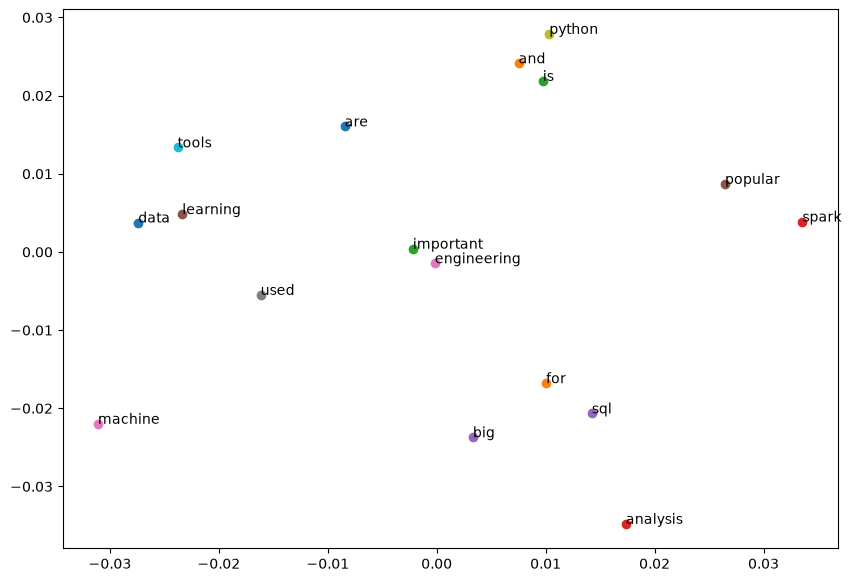

In [13]:
#word2vec visualization using PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)

vectors = [model.wv[word] for word in words]

pca = PCA(n_components=2)

result = pca.fit_transform(vectors)

plt.figure(figsize=(10, 7))

for i, word in enumerate(words):
    x = result[i][0]
    y = result[i][1]

    plt.scatter(x, y)
    plt.annotate(word, (x, y))

plt.show()